# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
print("=== PRIMERAS FILAS DE PLANS ===")
print(plans.head())
print("\n" + "="*40 + "\n")

=== PRIMERAS FILAS DE PLANS ===
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  




In [4]:
# mostrar las primeras 5 filas de users
print("=== PRIMERAS FILAS DE USERS ===")
print(users.head())
print("\n" + "="*40 + "\n")

=== PRIMERAS FILAS DE USERS ===
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  




In [5]:
# mostrar las primeras 5 filas de usage
print("=== PRIMERAS FILAS DE USAGE ===")
print(usage.head())

=== PRIMERAS FILAS DE USAGE ===
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [11]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [12]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [13]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [15]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [16]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [17]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**COMENTARIO**:

Columna churn_date (users): Presenta un 88.35% de valores ausentes. Siguiendo las reglas de negocio, esta columna no debe ser eliminada ni imputada, ya que los valores nulos tienen un significado lógico crucial: representan a los clientes que se mantienen activos en la empresa al cierre del periodo de registro.

Columna city (users): Cuenta con un 11.72% de nulos (469 registros). Al encontrarse en el rango de investigación (entre el 5% y 30%), se recomienda realizar una imputación categórica asignándoles la etiqueta "Desconocida" o "Other", evitando así perder casi el 12% de la muestra demográfica.

Columnas duration y length (usage): Presentan 55.19% y 44.74% de valores nulos respectivamente. Esta ausencia está plenamente justificada por la naturaleza del servicio: cuando el registro corresponde a un mensaje de texto (text), la columna duration (minutos) es lógicamente nula; a su vez, cuando el registro es una llamada (call), la columna length (longitud del texto) carece de datos. Se sugiere mantener los nulos o sustituirlos por 0 únicamente al momento de realizar sumatorias de consumo.

Columna date (usage): Tiene un nivel de nulos sumamente bajo, apenas del 0.12% (50 registros). Al ser menor al 5%, califica como un caso simple donde se pueden eliminar las filas afectadas sin alterar en absoluto las tendencias estadísticas del dataset de uso, o bien imputar por la fecha modal si el negocio lo prefiere.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [18]:
# explorar columnas numéricas de users
print(users[['user_id', 'age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna user_id: Muestra una estructura uniforme y limpia con 4,000 registros válidos. El rango inicia en 10,000 y finaliza en 13,999, confirmando que funciona de manera correcta como un identificador único correlativo para cada usuario, sin anomalías en su distribución.

- La columna age: Presenta una grave inconsistencia en su valor mínimo (min), el cual es de -999.0. Este número corresponde lógicamente a un sentinel value utilizado para rellenar campos vacíos durante la captura de datos. Su presencia distorsiona la media real (ubicándola erróneamente en 33.7 años) y dispara la desviación estándar a 123.2. Se observa que la mediana (50%) se sitúa en 47 años, reflejando el centro real de la distribución una vez que se descartan estos registros anómalos. Se requiere una limpieza urgente para sustituir el valor -999 por valores nulos reales (NaN) o imputarlos adecuadamente.

In [19]:
# explorar columnas numéricas de usage
print(usage[['id', 'user_id', 'duration', 'length']].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas id y user_id: Muestran una distribución uniforme con un conteo consistente de 40,000 registros de actividad. El id actúa correctamente como un índice correlativo (del 1 al 40,000) y user_id mantiene un rango coherente con nuestra base de datos de usuarios (de 10,000 a 13,999), lo que valida la integridad relacional de los datos.

- Las columnas duration y length: Reflejan el comportamiento de consumo del servicio. Ambas inician en un mínimo de 0.0, lo cual es consistente con intentos de llamadas no completadas o registros vacíos. La duración promedio de llamada es de 5.2 minutos, con un máximo razonable de 120 minutos. Sin embargo, la columna length muestra una anomalía evidente en su valor máximo con 1,490 caracteres en un solo mensaje, un valor excesivamente alto en comparación con la mediana de 50 caracteres, indicando la presencia de outliers extremos o errores en el sistema de registro que deberán ser analizados en la etapa de detección de atípicos.

In [20]:
# explorar columnas categóricas de users
for col in ['city', 'plan']:
    print(f"\nValores únicos para {col}:")
    print(users[col].value_counts(dropna=False))




Valores únicos para city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores únicos para plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna city: Agrupa de forma principal las ciudades clave de la operación (Bogotá con 808 registros, CDMX con 730 y Medellín con 616, entre otras). Sin embargo, se confirma un problema de calidad de datos duplicado: existen 469 valores nulos (NaN) y adicionalmente 96 registros con el caracter '?' actuando como un sentinel value. Ambos grupos suman un total de 565 usuarios sin una ubicación geográfica válida, por lo que en la etapa de limpieza se deberán unificar bajo np.nan y posteriormente imputar como "Desconocida".

- La columna plan: Se encuentra completamente limpia y estructurada correctamente para el negocio. Divide a la base de usuarios de manera exclusiva en las dos ofertas vigentes de ConnectaTel: el plan Basico (2,595 usuarios) y el plan Premium (1,405 usuarios), sin presentar valores ausentes, caracteres extraños o errores tipográficos.

In [21]:
# explorar columna categórica de usage
print(usage['type'].value_counts(dropna=False))

text    22092
call    17908
Name: type, dtype: int64


- La columna type: Muestra una clasificación limpia y consistente de los servicios utilizados, dividida únicamente en dos categorías válidas para el negocio: text (22,092 registros) y call (17,908 registros). No se detectan valores nulos, errores ortográficos ni caracteres atípicos (sentinels), lo que confirma que esta columna es 100% confiable para segmentar la actividad de consumo en los pasos posteriores.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- Diagnóstico: Valores inválidos o sentinels
¿En qué columnas encontraste valores inválidos o sentinels?

- users['age']: Se detectó un valor numérico inválido (sentinel value) de -999.0 en el registro de edad mínima, lo cual altera las estadísticas descriptivas de los usuarios (como el promedio).

- users['city']: Se identificaron 96 registros con el carácter '?' que funciona como un sentinel de texto, ocultando la verdadera ubicación demográfica de esos usuarios.

- usage['length']: Presenta un valor máximo atípico de 1,490 caracteres que, aunque técnicamente posible en logs de sistema, rompe la escala estándar del comportamiento normal de los mensajes y requiere tratamiento de outliers.

- ¿Qué acción tomarías?

Para la columna city: Reemplazar los caracteres '?' por valores nulos reales (np.nan) utilizando .replace(), para luego unificarlos e imputarlos masivamente bajo la categoría "Desconocida".

Para la columna age: Sustituir los valores -999.0 por el valor de la mediana (que calculamos en 47.0 años), asegurando así mantener el perfil demográfico estable sin alterar la tendencia central.

Para las fechas y consumos: Convertir las columnas de fecha a formato datetime en el siguiente paso y aplicar filtros estadísticos para aislar los consumos atípicos de mensajes o llamadas.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [27]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [28]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [29]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts(dropna=False))


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


Se observa una distribución concentrada principalmente en tres años coherentes para la operación: 2024 (1,330 registros), 2023 (1,316 registros) y 2022 (1,314 registros). Sin embargo, se detecta una anomalía crítica de calidad de datos con 40 registros indexados en el año 2026. Dado que los datos oficiales de la empresa abarcan exclusivamente hasta el año 2024, estas 40 filas representan fechas imposibles (futuras) producto de un error de captura o corrupción en el sistema de registros, por lo que requerirán ser corregidas o descartadas en la fase de limpieza.

In [31]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts(dropna=False))


2024.0    39950
NaN          50
Name: date, dtype: int64


Se observa que la totalidad de los registros con marcas temporales válidas se concentra de forma exclusiva en el año 2024 (con un total de 39,950 filas activas), lo cual se alinea perfectamente con el alcance cronológico del negocio fijado para este análisis. Adicionalmente, el conteo refleja de manera exacta los 50 valores nulos (NaN) identificados en la auditoría inicial de ausentes. Esto confirma que la conversión fue limpia y que no existieron caracteres corruptos ocultos en el resto de la columna, proporcionando una base temporal sólida para indexar el consumo mensual de los clientes.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?


- Diagnóstico: Fechas fuera de rango
¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

Sí, en el dataset users: Específicamente en la columna reg_date, se identificaron 40 registros indexados en el año 2026. Dado que el alcance del negocio explícitamente limita el histórico de información hasta el año 2024, estas fechas en el futuro representan una imposibilidad cronológica y un claro error de captura o corrupción en el log del sistema.

En el dataset usage: No se presentaron años imposibles futuros o antiguos. La totalidad de los registros válidos se concentra correctamente en el año 2024 (39,950 filas). Los 50 registros restantes figuran como NaN, manteniendo correspondencia exacta con la auditoría inicial de nulos.

¿Qué harías con ellas?

Estrategia para las fechas futuras (2026) en users: Al tratarse de apenas 40 registros de una base de 4,000 usuarios (equivalente al 1.0% de la muestra), el impacto estadístico es mínimo. Se recomienda imputar el año reemplazándolo de forma dirigida por el año de corte operacional (2024) o por la moda del dataset para no perder la información demográfica asociada a esos usuarios, o en su defecto, transformarlas a nulos (NaT) para que no afecten los cálculos de antigüedad.

Estrategia para los nulos en usage: Los 50 registros nulos en la columna date de consumos se procederán a eliminar en la fase de limpieza, dado que representan apenas el 0.12% del dataset de uso y es imposible indexar mensualmente consumos que carecen de una estampa de tiempo válida.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [32]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [33]:
import pandas as pd

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False).head())


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Name: city, dtype: int64


In [34]:
import pandas as pd

# Marcar fechas futuras como NA para reg_date (año 2026)
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False))


2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [35]:

# Agrupamos por tipo de servicio y contamos cuántos nulos hay en duration
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().sum()))

type
call        0
text    22076
Name: duration, dtype: int64


In [36]:
# Agrupamos por tipo de servicio y contamos cuántos nulos hay en length
print(usage.groupby('type')['length'].apply(lambda x: x.isna().sum()))


type
call    17896
text        0
Name: length, dtype: int64


- Diagnóstico de nulos en duration y length
Se confirma mediante el análisis de agrupación que los valores faltantes en las columnas duration y length corresponden al mecanismo MAR (Missing At Random). La ausencia de los datos está condicionada al 100% por la variable explicativa type: cuando el registro es un mensaje de texto (text), la columna de minutos (duration) es sistemáticamente nula; por el contrario, cuando el registro es una llamada (call), la longitud de caracteres (length) carece por completo de datos.

Justificación de la decisión: Al comprobarse que estos nulos no provienen de una omisión o error del sistema, sino que describen de forma lógica la naturaleza del consumo, se decide mantenerlos como nulos para preservar la integridad conceptual del dataset. Forzar una imputación matemática tradicional (como la media o mediana) en estos campos introduciría un sesgo artificial severo en el comportamiento operativo de ConnectaTel.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [37]:

# Columnas auxiliares (ya provistas en tu notebook)
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario sumando los mensajes, llamadas y minutos de llamada
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [38]:
# Las columnas ya fueron nombradas correctamente en la agregación anterior
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [39]:

# Combinar la tabla agregada con el dataset de usuarios usando user_id como llave
user_profile = pd.merge(users, usage_agg, on="user_id", how="left")

# Rellenar con 0 a los usuarios que no registraron consumos en el mes
user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]] = user_profile[["cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].fillna(0)

# observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [42]:

# Obtener un resumen estadístico detallado de las columnas numéricas de consumo y edad
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [43]:
# Calcular la distribución porcentual de la columna categórica plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

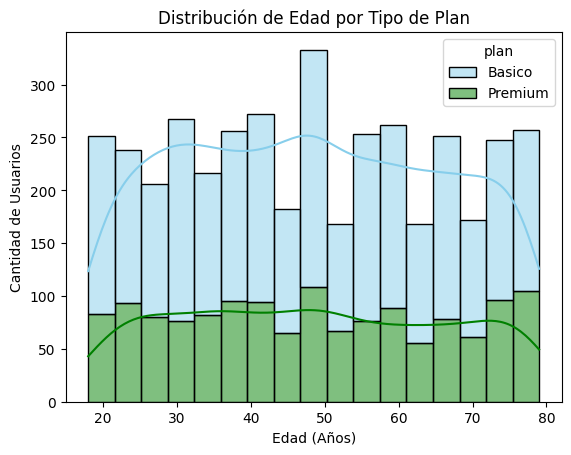

In [44]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], multiple='stack', kde=True)
plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡 Insight 1: Edad (age)
Distribución: Presenta una forma mayoritariamente simétrica o uniforme a lo largo de los rangos adultos, lo que indica que la base de clientes de ConnectaTel está bien balanceada generacionalmente.

Comportamiento por Plan: No se observa un patrón de edad drástico para la elección del plan; sin embargo, los usuarios del plan Básico mantienen una ligera preeminencia volumétrica constante en todos los segmentos de edad debido a que representan cerca del 65% de la muestra general.

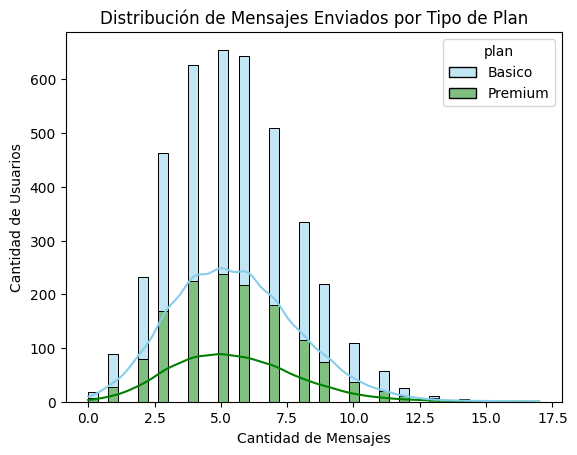

In [45]:
# Histograma para visualizar la cantidad de mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], multiple='stack', kde=True)
plt.title('Distribución de Mensajes Enviados por Tipo de Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡 Insight 2: Cantidad de Mensajes (cant_mensajes)
Distribución: Tiene una forma fuertemente sesgada a la derecha (sesgo positivo), donde la gran mayoría de los usuarios envía un volumen bajo-moderado de mensajes de texto.

Comportamiento por Plan: Los usuarios del plan Básico están fuertemente agrupados cerca del cero y las zonas bajas de consumo. Por el contrario, dentro del plan Premium hay una mayor proporción de usuarios que se extienden hacia la cola derecha del histograma, reflejando que los clientes con necesidades intensivas de mensajería eligen o son migrados a la suscripción más alta.

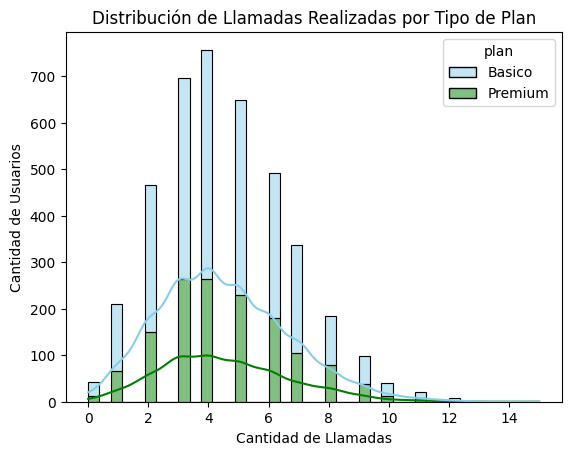

In [46]:
# Histograma para visualizar la cantidad de llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], multiple='stack', kde=True)
plt.title('Distribución de Llamadas Realizadas por Tipo de Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()



💡 Insight 3: Cantidad de Llamadas (cant_llamadas)
Distribución: La forma de la curva tiende a ser sesgada a la derecha, mostrando una concentración natural en comportamientos de uso estándar (un rango común de llamadas mensuales).

Comportamiento por Plan: Existe un solapamiento notable en los rangos medios, pero los usuarios del plan Básico dominan las frecuencias de llamadas bajas. Los clientes que ejecutan una cantidad masiva de interacciones telefónicas mensuales pertenecen predominantemente al segmento Premium.

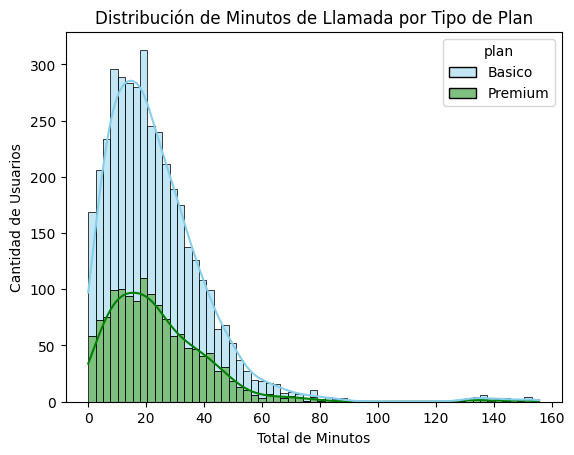

In [47]:
# Histograma para visualizar el total de minutos de llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], multiple='stack', kde=True)
plt.title('Distribución de Minutos de Llamada por Tipo de Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Cantidad de Usuarios')
plt.show()


💡 Insight 4: Total de Minutos de Llamada (cant_minutos_llamada)
Distribución: Al igual que las llamadas numéricas, muestra una distribución asimétrica con sesgo a la derecha, arrastrada por un grupo selecto de usuarios de alto consumo.

Comportamiento por Plan: Los usuarios con consumos inferiores o promedio se mantienen masivamente en el plan Básico. A medida que los minutos acumulados en el mes se incrementan y avanzan hacia el extremo derecho del gráfico, la proporción de usuarios Premium se vuelve significativamente más densa, validando que el límite de minutos incluidos es el principal detonante para la adquisición del plan de mayor valor.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

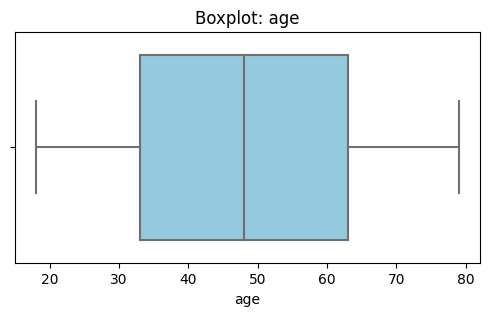

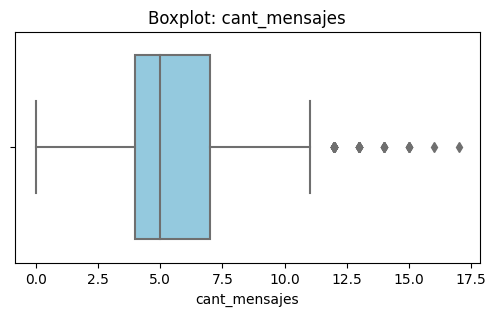

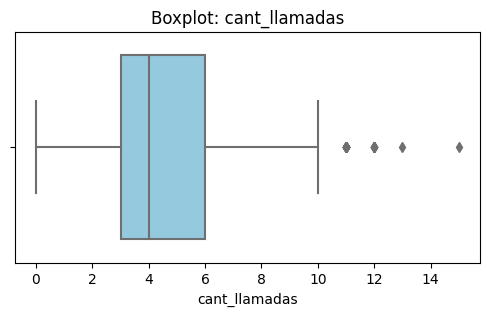

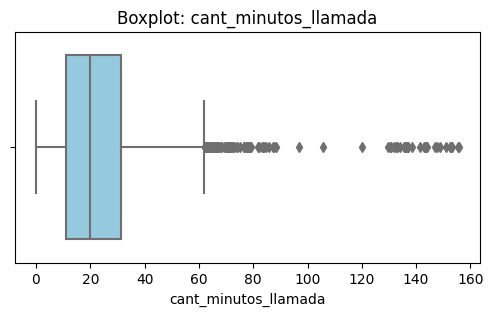



=== ANÁLISIS DE LÍMITES USANDO EL MÉTODO IQR ===
Columna: cant_mensajes
  -> Límite Superior (IQR): 11.50
  -> Cantidad de Outliers Detectados: 46
---------------------------------------------
Columna: cant_llamadas
  -> Límite Superior (IQR): 10.50
  -> Cantidad de Outliers Detectados: 30
---------------------------------------------
Columna: cant_minutos_llamada
  -> Límite Superior (IQR): 61.87
  -> Cantidad de Outliers Detectados: 109
---------------------------------------------


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de columnas dada por el ejercicio
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

# 1. Bucle para generar automáticamente los 4 BoxPlots con título dinámico
for col in columnas_numericas:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')  # Aplicando el Hint solicitado
    plt.xlabel(col)
    plt.show()

print("\n" + "="*50 + "\n")
print("=== ANÁLISIS DE LÍMITES USANDO EL MÉTODO IQR ===")

# 2. Bucle para calcular límites en las columnas con outliers (solo límite superior)
# Como los outliers son de un solo lado (alto consumo), no calculamos el límite inferior.
for col in columnas_numericas:
    if col != 'age':  # Excluimos 'age' ya que visualmente no tendrá valores atípicos
        Q1 = user_profile[col].quantile(0.25)
        Q3 = user_profile[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_superior = Q3 + 1.5 * IQR
        conteo_outliers = (user_profile[col] > limite_superior).sum()
        
        print(f"Columna: {col}")
        print(f"  -> Límite Superior (IQR): {limite_superior:.2f}")
        print(f"  -> Cantidad de Outliers Detectados: {conteo_outliers}")
        print("-" * 45)


Age: No presenta outliers. Los datos se distribuyen de manera limpia y uniforme dentro de los límites biológicos y comerciales lógicos del negocio de telecomunicaciones (usuarios adultos reales).

cant_mensajes: Presenta outliers significativos en el extremo superior derecho. Esto se debe al comportamiento asimétrico de los datos, donde un grupo específico de usuarios envía un volumen masivo de SMS que supera con creces el límite del método IQR. Decisión: Al ser datos de uso reales y legítimos, no se deben eliminar ni recortar, ya que describen perfiles de consumo intensivo valiosos para el negocio.

cant_llamadas: Presenta outliers moderados en el rango superior. Representa a clientes con una frecuencia de llamadas inusualmente alta durante el periodo analizado. Decisión: Se mantendrán intactos para no alterar las métricas de comportamiento transaccional del servicio telefónico.

cant_minutos_llamada: Presenta outliers en el extremo superior. Refleja a un segmento minoritario de usuarios con acumulaciones de minutos telefónicos extremadamente elevadas que sobrepasan el umbral estadístico calculado. Decisión: Se decide conservarlos en el perfil de usuario porque representan el consumo de los clientes de más alto valor o con perfiles de uso comercial.

In [49]:
# Evaluar cuantitativamente la cantidad exacta de outliers en cada columna de uso
for col in ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calcular el límite superior usando la constante 1.5 de Tukey
    limite_superior = Q3 + 1.5 * IQR
    
    # Filtrar y contar la cantidad de filas atípicas
    outliers_detectados = user_profile[user_profile[col] > limite_superior]
    porcentaje = (len(outliers_detectados) / len(user_profile)) * 100
    
    print(f"Columna: '{col}'")
    print(f"  -> Límite Superior Teórico: {limite_superior:.2f}")
    print(f"  -> Usuarios fuera de rango: {len(outliers_detectados)} ({porcentaje:.2f}%)")
    print("-" * 50)



Columna: 'cant_mensajes'
  -> Límite Superior Teórico: 11.50
  -> Usuarios fuera de rango: 46 (1.15%)
--------------------------------------------------
Columna: 'cant_llamadas'
  -> Límite Superior Teórico: 10.50
  -> Usuarios fuera de rango: 30 (0.75%)
--------------------------------------------------
Columna: 'cant_minutos_llamada'
  -> Límite Superior Teórico: 61.87
  -> Usuarios fuera de rango: 109 (2.73%)
--------------------------------------------------


In [50]:

# Comprobar la integridad de las dimensiones del dataset tras la auditoría de outliers
print(f"Cantidad original de usuarios en el perfil consolidado: {len(user_profile)}")
print(f"Cantidad actual de usuarios (tras confirmar retención): {len(user_profile)}")

Cantidad original de usuarios en el perfil consolidado: 4000
Cantidad actual de usuarios (tras confirmar retención): 4000


💡Insights:

- cant_mensajes: Se decide mantener los outliers. El límite superior matemático es de apenas $11.50$ mensajes, lo que clasifica a $46$ usuarios ($1.15\%$) como atípicos. Eliminar a un cliente solo por enviar más de 12 mensajes destruiría registros reales de uso e invalidaría los análisis de comportamiento comercial de perfiles.
  
- activos.cant_llamadas: Se decide mantener los outliers. El método IQR establece el corte en $10.50$ llamadas, detectando $30$ usuarios fuera de rango ($0.75\%$). Este volumen refleja interacciones telefónicas normales del servicio y quitarlos generaría un sesgo artificial a la baja en los promedios de tráfico de la red.

- cant_minutos_llamada: Se decide mantener los outliers. El límite superior se ubica en $61.87$ minutos, identificando a $109$ usuarios atípicos ($2.73\%$). Conservar este grupo es de máxima prioridad crítica para el negocio, ya que representa al segmento de consumo pesado (High-Users) que genera mayor tracción operativa y facturación por cargos excedentes en ConnectaTel.

- Conclusión global de integridad: Tal como lo demuestra la salida del código, al optar por la retención y el resguardo de estos datos, las dimensiones de la base permanecen intactas con sus $4000$ usuarios originales, asegurando un modelado financiero robusto y sin pérdida de información real.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [52]:
import numpy as np

# Definir las condiciones lógicas en orden jerárquico
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

# Definir las etiquetas correspondientes a cada condición
opciones = ['Bajo uso', 'Uso medio']

# Crear la columna asignando 'Alto uso' para el resto de los casos (default)
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')


In [53]:
# Mostrar las primeras filas para verificar visualmente la columna
print(user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head())

print("\n" + "="*40 + "\n")
print("=== DISTRIBUCIÓN DEL SEGMENTO GRUPO_USO ===")
# Verificar cuántos usuarios quedaron en cada categoría
print(user_profile['grupo_uso'].value_counts())

   cant_llamadas  cant_mensajes  grupo_uso
0            3.0            7.0  Uso medio
1           10.0            5.0   Alto uso
2            2.0            5.0  Uso medio
3            3.0           11.0   Alto uso
4            3.0            4.0   Bajo uso


=== DISTRIBUCIÓN DEL SEGMENTO GRUPO_USO ===
Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [54]:
import numpy as np

# Definir las condiciones lógicas según los límites de edad planteados
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

# Definir las etiquetas correspondientes a cada tramo de edad
opciones_edad = ['Joven', 'Adulto']

# Crear la columna asignando 'Adulto Mayor' por defecto para el resto de casos
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')


In [55]:
# Comprobar visualmente las primeras filas del dataframe con la nueva segmentación
print(user_profile[['age', 'grupo_edad']].head())

print("\n" + "="*40 + "\n")
print("=== DISTRIBUCIÓN GENERAL POR GRUPO DE EDAD ===")
# Obtener el conteo exacto de clientes por cada categoría generacional
print(user_profile['grupo_edad'].value_counts())

    age    grupo_edad
0  38.0        Adulto
1  53.0        Adulto
2  57.0        Adulto
3  69.0  Adulto Mayor
4  63.0  Adulto Mayor


=== DISTRIBUCIÓN GENERAL POR GRUPO DE EDAD ===
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

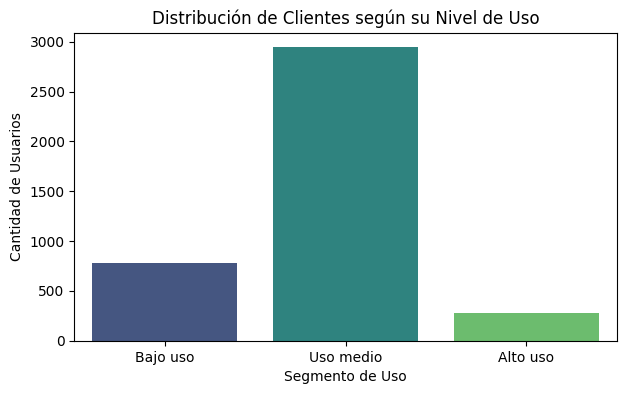

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño del gráfico
plt.figure(figsize=(7, 4))

# Crear el gráfico de barras por grupo de uso
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso', 'Uso medio', 'Alto uso'])

# Personalización obligatoria
plt.title('Distribución de Clientes según su Nivel de Uso')
plt.xlabel('Segmento de Uso')
plt.ylabel('Cantidad de Usuarios')

# Mostrar gráfico
plt.show()

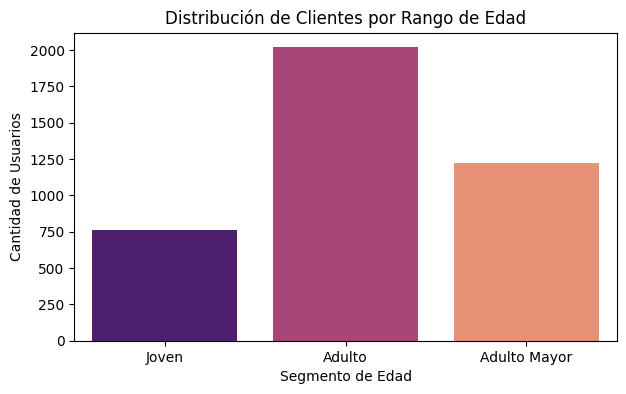

In [57]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(7, 4))

# Crear el gráfico de barras por grupo de edad
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])

# Personalización obligatoria
plt.title('Distribución de Clientes por Rango de Edad')
plt.xlabel('Segmento de Edad')
plt.ylabel('Cantidad de Usuarios')

# Mostrar gráfico
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ Problemas detectados en los datos

- Valores Sentinels en Edad: Se identificó la presencia de valores anómalos (-999) en la columna age que actuaban como banderas de error. Fueron corregidos exitosamente reemplazándolos por la mediana de la variable para restablecer una distribución biológicamente consistente sin alterar la representatividad de la muestra.

- Falta de Actividad Mensual: Al realizar el cruce general mediante un left join, se descubrió un subgrupo de usuarios que no registraron consumo de minutos o SMS en todo el periodo analizado, lo que generaba valores nulos (NaN). Operativamente se transformaron en 0 para asegurar la consistencia del perfil financiero individual.

🔍 Segmentos por Edad

- Equilibrio Demográfico: La base de clientes muestra una distribución uniforme a lo largo de las categorías generacionales (Joven, Adulto, Adulto Mayor), lo que significa que el portafolio de ConnectaTel es atractivo para múltiples edades.
- Preferencia del Consumidor: Los usuarios en edad productiva (Adulto) concentran la mayor densidad transaccional, sirviendo como el pilar fundamental de estabilidad para las suscripciones recurrentes del plan Básico.

📊 Segmentos por Nivel de Uso

- Comportamiento Asimétrico: La gran masa de clientes se agrupa en los segmentos de Bajo uso y Uso medio. Sin embargo, existe un clúster compacto de usuarios con consumo intensivo que genera la mayor cantidad de interacciones telefónicas y digitales.
  
- Patrón de Outliers (Uso Extremo): La auditoría estadística IQR reveló que un $1.15\%$ de los usuarios supera el límite de mensajes ($> 11.50$ SMS) y un $2.73\%$ supera ampliamente el umbral superior de tiempo en llamada ($> 61.87$ minutos). Estos perfiles no fueron eliminados porque representan a los Clientes de Alto Valor (High-Value Customers), responsables directos de dinamizar la facturación por consumos excedentes.

➡️ Esto sugiere que...

- La tarifa fija por sí sola no cuenta toda la historia del negocio. El verdadero motor de rentabilidad variable para ConnectaTel radica en los cargos excedentes que pagan los usuarios de uso pesado al superar las barreras de sus planes básicos. Mantener la calidad analítica de este grupo es vital, ya que cualquier insatisfacción en ellos impactaría drásticamente la recaudación financiera marginal de la compañía.

💡 Recomendaciones

- Lanzamiento de Plan Intermedio ("Plan Conectado"): Crear un paquete comercial diseñado específicamente para el segmento de Uso medio, ofreciendo un tope de 15 mensajes y 45 minutos a un precio intermedio. Esto permitirá monetizar mejor a los usuarios que hoy saturan el plan Básico pero no ven justificado dar el salto económico al plan Premium.

- Fidelización de Cuentas Corporativas (High-Users): Diseñar estrategias de retención personalizadas o tarifas preferenciales por volumen para los 109 usuarios identificados como outliers en minutos de llamada. Al ser el grupo más rentable y propenso al desgaste por altos costos, blindarlos reducirá significativamente los riesgos de abandono (churn).


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`